# Step 3: Ekstraksi Fitur

Mengekstrak **98 fitur** sesuai **C23 Tabel 2** dari data kartu dan bidding:

| Fitur | Deskripsi | Range |
|-------|-----------|-------|
| `player_hcp_[suit]` | HCP North per suit (A=4,K=3,Q=2,J=1) | 0-10 |
| `partner_hcp_[suit]` | HCP South per suit | 0-10 |
| `total_hcp` | Total HCP NS gabungan | 0-40 |
| `total_num_[suit]` | Jumlah kartu NS per suit | 0-26 |
| `player_balance` | Label distribusi North | 0-3 |
| `partner_balance` | Label distribusi South | 0-3 |
| `total_stop_[suit]` | Stopper NS terkuat | 0-3 |
| `vulnerability` | Kode vulnerability | 1-4 |
| `dealer_[N/E/S/W]` | One-hot dealer | 0/1 |
| `bid_00..bid_71` | 72-bit bidding history one-hot | 0/1 |

**Prasyarat:** Jalankan `01_parsing.ipynb` terlebih dahulu.

In [1]:
import sys
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PARSED    = Path(ROOT) / "data" / "parsed"
DATA_PROCESSED = Path(ROOT) / "data" / "processed"
RESULTS        = Path(ROOT) / "results"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
(RESULTS / "figures").mkdir(parents=True, exist_ok=True)

PARSED_CSV  = DATA_PARSED / "parsed_boards.csv"
FEATURES_CSV = DATA_PROCESSED / "features.csv"

print(f"Root proyek : {ROOT}")
print("Setup selesai.")

Root proyek : d:\SkripsiBBO
Setup selesai.


In [2]:
df_parsed = pd.read_csv(PARSED_CSV)
print(f"Loaded: {df_parsed.shape[0]} baris dari parsed_boards.csv")

Loaded: 8397 baris dari parsed_boards.csv


## 3.1 Demo: Komponen Fitur Individual

Memahami cara kerja setiap komponen fitur sebelum ekstraksi massal.

In [3]:
from features import parse_hand, hcp_per_suit, classify_balance, classify_stopper

sample_row = df_parsed.iloc[0]
north_str  = str(sample_row["north_hand_norm"])
north_hand = parse_hand(north_str)

print(f"Hand North: {north_str}")
print(f"  Parsed  : {north_hand}")
print()
hcp = hcp_per_suit(north_hand)
print(f"HCP per suit: {hcp}")
print(f"Total HCP North: {sum(hcp.values())}")
print(f"Balance label: {classify_balance(north_hand)} "
      f"(0=seimbang, 1=cukup seimbang, 2=cukup tidak, 3=tidak seimbang)")
print()
for suit, name in [("S","Spade"),("H","Heart"),("D","Diamond"),("C","Club")]:
    stop = classify_stopper(north_hand[suit])
    stop_label = ["no stopper", "unknown", "partial stopper", "full stopper"][stop]
    print(f"  Stopper {name}: {stop} ({stop_label}) — cards: {north_hand[suit]}")

Hand North: SKT87HT76D873C743
  Parsed  : {'S': ['K', 'T', '8', '7'], 'H': ['T', '7', '6'], 'D': ['8', '7', '3'], 'C': ['7', '4', '3']}

HCP per suit: {'S': 3, 'H': 0, 'D': 0, 'C': 0}
Total HCP North: 3
Balance label: 0 (0=seimbang, 1=cukup seimbang, 2=cukup tidak, 3=tidak seimbang)

  Stopper Spade: 3 (full stopper) — cards: ['K', 'T', '8', '7']
  Stopper Heart: 0 (no stopper) — cards: ['T', '7', '6']
  Stopper Diamond: 0 (no stopper) — cards: ['8', '7', '3']
  Stopper Club: 0 (no stopper) — cards: ['7', '4', '3']


In [4]:
from features import extract_features

feat = extract_features(df_parsed.iloc[0])

print("=== Contoh Fitur dari Satu Board ===")
print(f"North: {df_parsed.iloc[0]['north_hand_norm']}")
print(f"South: {df_parsed.iloc[0]['south_hand_norm']}")
print()
main_features = {k: v for k, v in feat.items() if not k.startswith("bid_")}
for k, v in main_features.items():
    print(f"  {k:<25} = {v}")

bid_features = {k: v for k, v in feat.items() if k.startswith("bid_")}
n_active = sum(1 for v in bid_features.values() if v == 1)
print(f"\n72-bit bidding history: {n_active} bit aktif dari 72")

=== Contoh Fitur dari Satu Board ===
North: SKT87HT76D873C743
South: SJ9HAQ9DQJT96CJ95

  player_hcp_spade          = 3
  player_hcp_heart          = 0
  player_hcp_diamond        = 0
  player_hcp_club           = 0
  partner_hcp_spade         = 1
  partner_hcp_heart         = 6
  partner_hcp_diamond       = 3
  partner_hcp_club          = 1
  total_hcp                 = 14
  total_num_spade           = 6
  total_num_heart           = 6
  total_num_diamond         = 8
  total_num_club            = 6
  player_balance            = 0
  partner_balance           = 0
  total_stop_spade          = 3
  total_stop_heart          = 3
  total_stop_diamond        = 2
  total_stop_club           = 2
  vulnerability             = 4
  dealer_N                  = 1
  dealer_E                  = 0
  dealer_S                  = 0
  dealer_W                  = 0
  ns_best_fit               = 8
  ns_best_major_fit         = 6

72-bit bidding history: 2 bit aktif dari 72


## 3.2 Ekstraksi Fitur dari Seluruh Dataset

In [5]:
from features import extract_all, FEATURE_COLS

print(f"Target fitur model: {len(FEATURE_COLS)} fitur")
print("Mengekstrak fitur dari seluruh dataset...")

df_features = extract_all(df_parsed, verbose=True)
df_features.to_csv(FEATURES_CSV, index=False)

print(f"\nHasil ekstraksi fitur:")
print(f"  Shape  : {df_features.shape}")
print(f"  Disimpan ke: {FEATURES_CSV}")

Target fitur model: 98 fitur
Mengekstrak fitur dari seluruh dataset...
Mengekstrak fitur dari 8397 baris...
  1000/8397 selesai
  2000/8397 selesai
  3000/8397 selesai
  4000/8397 selesai
  5000/8397 selesai
  6000/8397 selesai
  7000/8397 selesai
  8000/8397 selesai
Selesai. Shape: (8397, 104)

Hasil ekstraksi fitur:
  Shape  : (8397, 104)
  Disimpan ke: d:\SkripsiBBO\data\processed\features.csv


## 3.3 Statistik Fitur

In [6]:
non_bid_cols = [c for c in FEATURE_COLS if not c.startswith("bid_") and c in df_features.columns]
print(f"Fitur non-bid tersedia: {len(non_bid_cols)}")
df_features[non_bid_cols].describe().round(2)

Fitur non-bid tersedia: 26


,player_hcp_spade,player_hcp_heart,player_hcp_diamond,player_hcp_club,partner_hcp_spade,partner_hcp_heart,partner_hcp_diamond,partner_hcp_club,total_hcp,total_num_spade,...,total_stop_heart,total_stop_diamond,total_stop_club,vulnerability,dealer_N,dealer_E,dealer_S,dealer_W,ns_best_fit,ns_best_major_fit
count,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00,...,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00,8397.00
mean,2.45,2.50,2.44,2.50,2.54,2.52,2.48,2.52,19.96,6.49,...,2.63,2.62,2.64,2.52,0.26,0.26,0.24,0.24,8.32,7.48
std,2.28,2.29,2.30,2.33,2.33,2.33,2.31,2.31,4.94,1.61,...,0.77,0.78,0.76,1.12,0.44,0.44,0.43,0.43,0.99,1.25
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,5.00,...,2.00,2.00,3.00,2.00,0.00,0.00,0.00,0.00,8.00,7.00
50%,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,20.00,6.00,...,3.00,3.00,3.00,3.00,0.00,0.00,0.00,0.00,8.00,7.00
75%,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,23.00,8.00,...,3.00,3.00,3.00,4.00,1.00,1.00,0.00,0.00,9.00,8.00
max,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,36.00,12.00,...,3.00,3.00,3.00,4.00,1.00,1.00,1.00,1.00,12.00,12.00


In [7]:
available = [c for c in FEATURE_COLS if c in df_features.columns]
missing_feat = [c for c in FEATURE_COLS if c not in df_features.columns]
print(f"FEATURE_COLS tersedia: {len(available)}/{len(FEATURE_COLS)}")
if missing_feat:
    print(f"\nFitur tidak tersedia: {missing_feat[:10]}{'...' if len(missing_feat) > 10 else ''}")
else:
    print("Semua fitur tersedia!")

FEATURE_COLS tersedia: 98/98
Semua fitur tersedia!


## 3.4 Visualisasi Distribusi Fitur Utama

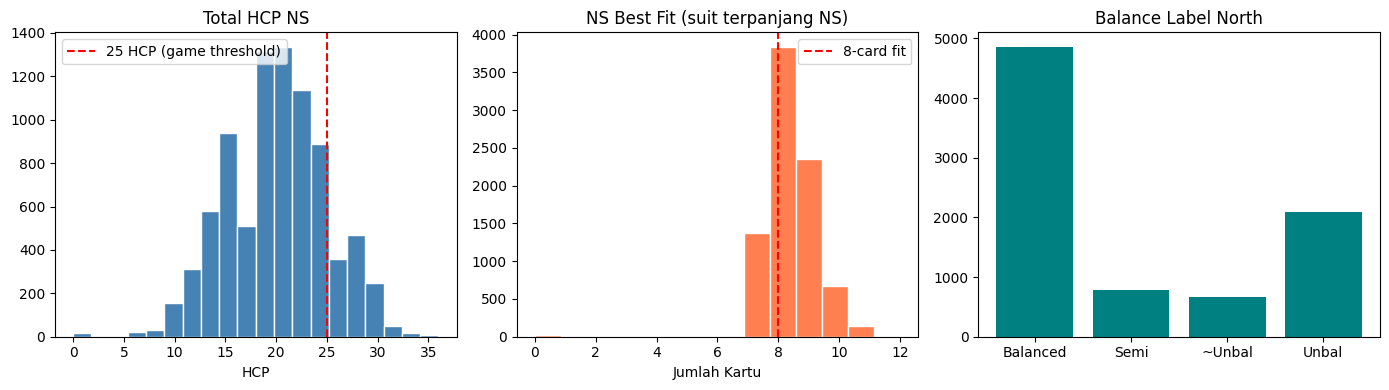

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

if "total_hcp" in df_features.columns:
    axes[0].hist(df_features["total_hcp"].dropna(), bins=20, color="steelblue", edgecolor="white")
    axes[0].set_title("Total HCP NS")
    axes[0].set_xlabel("HCP")
    axes[0].axvline(25, color="red", linestyle="--", label="25 HCP (game threshold)")
    axes[0].legend()

if "ns_best_fit" in df_features.columns:
    axes[1].hist(df_features["ns_best_fit"].dropna(), bins=14, color="coral", edgecolor="white")
    axes[1].set_title("NS Best Fit (suit terpanjang NS)")
    axes[1].set_xlabel("Jumlah Kartu")
    axes[1].axvline(8, color="red", linestyle="--", label="8-card fit")
    axes[1].legend()

if "player_balance" in df_features.columns:
    bal_counts = df_features["player_balance"].value_counts().sort_index()
    axes[2].bar(bal_counts.index, bal_counts.values, color="teal")
    axes[2].set_title("Balance Label North")
    axes[2].set_xticks([0, 1, 2, 3])
    axes[2].set_xticklabels(["Balanced", "Semi", "~Unbal", "Unbal"])

plt.tight_layout()
plt.savefig(RESULTS / "figures" / "eda_features.png", dpi=150)
plt.show()

---
## Output

File yang dihasilkan:
- `data/processed/features.csv` — 98+ fitur per board

**Langkah berikutnya:** Buka `04_labeling.ipynb` untuk DDS labeling.